# Chest X-ray — Fast In-Memory Notebook

20-class chest pathology classification.  
Metric: `score = mean( (TP - FP - 5*FN) / (count + 1e-9) )`

**Key change:** All training images pre-loaded into RAM at 224x224 (uint8).  
Epochs become GPU-bound (~2 min) instead of disk-bound (~26 min).  
Backbone: EfficientNetV2-S | 5 folds x 15 epochs  
**Est. runtime: 2.5-4h on T4**

In [1]:
%pip install -q timm==1.0.8
%pip install -q albumentations==1.4.21

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.9/227.9 kB 5.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, math, random, time, datetime, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import timm
from timm.data.mixup import Mixup
from timm.utils import ModelEmaV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

T0 = time.time()
def elapsed(): return str(datetime.timedelta(seconds=int(time.time()-T0)))
def eta_str(done, total, t0):
    if done==0: return 'N/A'
    return str(datetime.timedelta(seconds=int((time.time()-t0)/done*(total-done))))

# CUDA sanity check (legacy torch.cuda.amp API)
CUDA_OK = torch.cuda.is_available()
if CUDA_OK:
    torch.cuda.set_device(0)
    _t = torch.zeros(4, 4, device='cuda'); torch.cuda.synchronize(); del _t
    print(f'CUDA OK: {torch.cuda.get_device_name(0)}')
print('Imports OK.')

CUDA OK: Tesla T4
Imports OK.


In [3]:
# ─── Config ────────────────────────────────────────────────────────────────────
DATA_CANDIDATES = [
    Path('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1'),
    Path('/kaggle/input/26-t-1-dl-gen-ainppe-1'),
    Path('dataset/26-t-1-dl-gen-ainppe-1'),
]
DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), None)
assert DATA_DIR is not None, 'Dataset not found'
IMG_DIR    = DATA_DIR / 'images'
TRAIN_CSV  = DATA_DIR / 'train.csv'
TEST_CSV   = DATA_DIR / 'test.csv'
SAMPLE_SUB = DATA_DIR / 'sample_submission.csv'
OUTPUT_SUB = Path('submission.csv')
CKPT_DIR   = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

# ── Speed trick: cache images at 224x224 uint8 ────────────────────────────────
# With workers=0, disk loading = 26 min/epoch. Caching once makes it ~2 min/epoch.
# 51k images x 224x224x3 uint8 = 7.7 GB RAM (Kaggle gives 13 GB)
CACHE_SIZE = 224   # cache resolution
IMG_SIZE   = 224   # training/inference resolution (matches cache)

BATCH_SIZE   = 64   # can use bigger batch with 224px (less VRAM per batch)
EPOCHS       = 15   # more epochs since each epoch is now fast
LR           = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0    # MUST stay 0 on Kaggle
N_FOLDS      = 5
FOLDS_TO_RUN = list(range(N_FOLDS))
SEED         = 42

MIXUP_ALPHA     = 0.2
CUTMIX_ALPHA    = 0.3
MIXUP_PROB      = 0.3
MODEL_EMA_DECAY = 0.9998
LABEL_SMOOTH    = 0.05
GRAD_CLIP       = 1.0
USE_AMP         = CUDA_OK

# EfficientNetV2-S: ~24M params, fast, pretrained on ImageNet-21k
BACKBONE = 'tf_efficientnetv2_s.in21k'

DEVICE = torch.device('cuda:0' if CUDA_OK else 'cpu')

def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)
print(f'Device  : {DEVICE}')
print(f'Data    : {DATA_DIR}')
print(f'Config  : IMG={IMG_SIZE} CACHE={CACHE_SIZE} BS={BATCH_SIZE} EP={EPOCHS} FOLDS={N_FOLDS}')
print(f'Backbone: {BACKBONE}')
print(f'Est. training time: {N_FOLDS*EPOCHS*2//60}h ({N_FOLDS}fx{EPOCHS}epx~2min/ep) + ~15min cache')

Device  : cuda:0
Data    : /kaggle/input/competitions/26-t-1-dl-gen-ainppe-1
Config  : IMG=224 CACHE=224 BS=64 EP=15 FOLDS=5
Backbone: tf_efficientnetv2_s.in21k
Est. training time: 2h (5fx15epx~2min/ep) + ~15min cache


In [4]:
train_df   = pd.read_csv(TRAIN_CSV)
test_df    = pd.read_csv(TEST_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)

id_col      = sample_sub.columns[0]
class_cols  = sample_sub.columns[1:]
num_classes = len(class_cols)
assert id_col == 'id'
print(f'Train: {len(train_df):,} | Test: {len(test_df):,} | Classes: {num_classes}')

train_df['target'] = train_df[class_cols].values.argmax(axis=1)
class_counts = train_df['target'].value_counts().sort_index()

# Sqrt+clip class weights — prevents class-19 gradient collapse
raw_w = np.sqrt(class_counts.sum() / (class_counts.values + 1e-6))
raw_w = raw_w / raw_w.mean()
class_weights = np.clip(raw_w, 0.5, 5.0).astype(np.float32)
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print('Class weights (sqrt+clipped, max 10x ratio):')
for i, (c, w) in enumerate(zip(class_counts.values, class_weights)):
    print(f'  {i:2d}: n={c:6d}  w={w:.3f}  {chr(9608)*int(w*8)}')

Train: 51,043 | Test: 17,015 | Classes: 20
Class weights (sqrt+clipped, max 10x ratio):
   0: n=  2351  w=0.467  ███
   1: n=   600  w=0.467  ███
   2: n=   651  w=0.467  ███
   3: n=   326  w=0.623  ████
   4: n=  2156  w=0.467  ███
   5: n=   172  w=0.857  ██████
   6: n=   389  w=0.570  ████
   7: n=    37  w=1.848  ██████████████
   8: n=  5206  w=0.467  ███
   9: n=  1249  w=0.467  ███
  10: n=  1527  w=0.467  ███
  11: n=   608  w=0.467  ███
  12: n=   160  w=0.889  ███████
  13: n=  1114  w=0.467  ███
  14: n=    44  w=1.695  █████████████
  15: n=     5  w=4.669  █████████████████████████████████████
  16: n=    24  w=2.295  ██████████████████
  17: n=   254  w=0.705  █████
  18: n=    91  w=1.179  █████████
  19: n= 34079  w=0.467  ███


### Pre-load all images into RAM (one-time, ~10-15 min)
This is the key speedup: from 26 min/epoch to ~2 min/epoch.

In [5]:
def load_image_cache(df_or_list, img_dir, cache_size, desc='Caching'):
    """Load images from disk into a uint8 numpy array (no disk I/O during training)."""
    ids = df_or_list[id_col].values if hasattr(df_or_list, id_col) else df_or_list
    if hasattr(df_or_list, id_col):
        ids = df_or_list[id_col].values
    else:
        ids = df_or_list
    N = len(ids)
    cache = np.empty((N, cache_size, cache_size, 3), dtype=np.uint8)
    for i, img_id in enumerate(tqdm(ids, desc=desc, ncols=100)):
        with Image.open(img_dir / img_id) as img:
            img = img.convert('RGB')
            if img.size != (cache_size, cache_size):
                img = img.resize((cache_size, cache_size), Image.BILINEAR)
            cache[i] = np.array(img, dtype=np.uint8)
    return cache

cache_t0 = time.time()
train_cache = load_image_cache(train_df, IMG_DIR, CACHE_SIZE, 'Caching train')
test_cache  = load_image_cache(test_df,  IMG_DIR, CACHE_SIZE, 'Caching test ')
cache_time  = str(datetime.timedelta(seconds=int(time.time()-cache_t0)))

train_targets_all = train_df['target'].values.astype(np.int64)
test_ids_all      = test_df[id_col].values

ram_gb = (train_cache.nbytes + test_cache.nbytes) / 1e9
print(f'Cache complete in {cache_time}')
print(f'RAM used: {ram_gb:.1f} GB  |  train: {train_cache.shape}  test: {test_cache.shape}')

Caching train:   0%|                                                      | 0/51043 [00:00<?, ?it/s]

Caching test :   0%|                                                      | 0/17015 [00:00<?, ?it/s]

Cache complete in 0:13:07
RAM used: 10.2 GB  |  train: (51043, 224, 224, 3)  test: (17015, 224, 224, 3)


In [6]:
assert (train_df[class_cols].sum(axis=1) == 1).all()
print(f'Missing images: {sum(1 for f in train_df[id_col] if not (IMG_DIR/f).exists())}')

Missing images: 0


### EDA

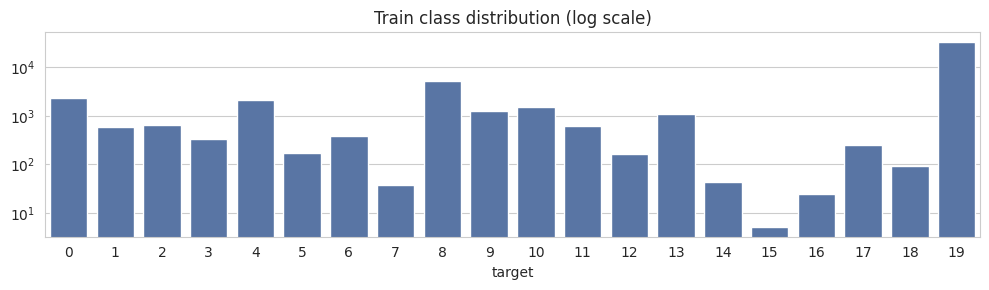

Majority: cls 19 (34,079=66.8%)  Rarest: cls 15 (5)


In [7]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10,3))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, color='#4c72b0')
ax.set_yscale('log'); ax.set_title('Train class distribution (log scale)')
plt.tight_layout(); plt.show()
cc = class_counts
print(f'Majority: cls {cc.idxmax()} ({cc.max():,}={cc.max()/len(train_df)*100:.1f}%)  Rarest: cls {cc.idxmin()} ({cc.min()})')

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(train=True):
    if train:
        return A.Compose([
            # No Resize needed — images already at CACHE_SIZE from RAM
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.08, rotate_limit=8, border_mode=0, p=0.5),
            A.RandomResizedCrop(IMG_SIZE, IMG_SIZE, scale=(0.85,1.0), ratio=(0.95,1.05), p=0.5),
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8,8), p=0.4),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.20, p=0.5),
            A.RandomGamma(gamma_limit=(80,120), p=0.3),
            A.GaussNoise(var_limit=(5.0,15.0), p=0.2),
            A.GaussianBlur(blur_limit=(3,5), p=0.1),
            A.CoarseDropout(max_holes=4, max_height=24, max_width=24, min_holes=1, min_height=8, min_width=8, p=0.2),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

In [9]:
class TrainDataset(Dataset):
    """Index into the pre-loaded uint8 cache. No disk I/O, no copy overhead."""
    def __init__(self, cache, indices, targets, transform):
        self.cache     = cache
        self.indices   = indices
        self.targets   = targets
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i   = self.indices[idx]
        img = self.cache[i].copy()   # copy avoids albumentations in-place issue
        if self.transform: img = self.transform(image=img)['image']
        return img, int(self.targets[i])

class TestDataset(Dataset):
    def __init__(self, cache, ids, transform):
        self.cache     = cache
        self.ids       = ids
        self.transform = transform
    def __len__(self): return len(self.cache)
    def __getitem__(self, idx):
        img = self.cache[idx].copy()
        if self.transform: img = self.transform(image=img)['image']
        return img, self.ids[idx]

In [10]:
def competition_score(y_true, y_pred, nc):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(nc)))
    tp = np.diag(cm); fp = cm.sum(0)-tp; fn = cm.sum(1)-tp
    return ((tp - fp - 5*fn) / (cm.sum(1)+1e-9)).mean()

In [11]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def make_loaders(fold):
    splits = list(skf.split(np.arange(len(train_df)), train_targets_all))
    ti, vi = splits[fold]
    tl = DataLoader(
        TrainDataset(train_cache, ti, train_targets_all, get_transforms(True)),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
    vl = DataLoader(
        TrainDataset(train_cache, vi, train_targets_all, get_transforms(False)),
        batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=False)
    return tl, vl, ti, vi

In [12]:
class GeMPooling(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1)*p); self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), 1).pow(1.0/self.p).flatten(1)

class CXRModel(nn.Module):
    def __init__(self, backbone_name, nc, pretrained=True, drop_path_rate=0.1):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            num_classes=0, global_pool='', drop_path_rate=drop_path_rate)
        self.pool = GeMPooling(p=3)
        self.drop = nn.Dropout(0.3)
        self.head = nn.Linear(self.backbone.num_features, nc)
    def forward(self, x):
        return self.head(self.drop(self.pool(self.backbone(x))))

def build_model():
    m = CXRModel(BACKBONE, num_classes, pretrained=True, drop_path_rate=0.1).to(DEVICE)
    if CUDA_OK: torch.cuda.synchronize()
    return m

def create_optimizer(model, epochs):
    bp = [p for n,p in model.named_parameters() if 'head' not in n]
    hp = [p for n,p in model.named_parameters() if 'head' in n]
    opt = torch.optim.AdamW([{'params':bp,'lr':LR*0.1},{'params':hp,'lr':LR}], weight_decay=WEIGHT_DECAY)
    w = LinearLR(opt, start_factor=0.05, end_factor=1.0, total_iters=2)
    c = CosineAnnealingLR(opt, T_max=max(epochs-2,1), eta_min=LR*0.005)
    return opt, SequentialLR(opt, [w,c], milestones=[2])

def create_mixup():
    return Mixup(mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
                 prob=MIXUP_PROB, switch_prob=0.5, mode='batch',
                 label_smoothing=LABEL_SMOOTH, num_classes=num_classes)

In [13]:
def weighted_soft_ce(logits, toh):
    lp = torch.log_softmax(logits, dim=1)
    return -(toh * class_weights_tensor.unsqueeze(0) * lp).sum(1).mean()

def train_one_epoch(model, loader, opt, scaler, mix_fn, ema, epoch):
    model.train()
    tot_l = tot_c = tot_n = 0
    pbar = tqdm(loader, leave=False, desc=f'  Train e{epoch:02d}', ncols=100)
    for imgs, targets in pbar:
        imgs    = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        hard    = targets.clone()
        use_mix = mix_fn if (epoch > 3 and mix_fn) else None
        if use_mix:
            imgs, tsoft = use_mix(imgs, targets)
        else:
            tsoft = torch.zeros(targets.size(0), num_classes, dtype=torch.float32, device=DEVICE)
            tsoft.scatter_(1, targets.view(-1,1), 1.0)
            tsoft.mul_(1 - LABEL_SMOOTH).add_(LABEL_SMOOTH / num_classes)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = weighted_soft_ce(logits, tsoft)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        if ema: ema.update(model)
        with torch.no_grad():
            tot_c += (logits.argmax(1)==hard).sum().item()
            tot_n += imgs.size(0)
            tot_l += loss.item()*imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{tot_c/tot_n:.3f}')
    return tot_l/tot_n, tot_c/tot_n

@torch.no_grad()
def evaluate(model, loader, ema):
    em = ema.module if ema else model
    em.eval()
    tot_l = tot_c = tot_n = 0
    pa, ta, pra = [], [], []
    for imgs, targets in tqdm(loader, leave=False, desc='  Val  ', ncols=100):
        imgs    = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = em(imgs)
        loss  = F.cross_entropy(logits, targets)
        probs = torch.softmax(logits, 1)
        preds = logits.argmax(1)
        tot_c += (preds==targets).sum().item()
        tot_n += imgs.size(0)
        tot_l += loss.item()*imgs.size(0)
        pa.append(preds.cpu().numpy()); ta.append(targets.cpu().numpy()); pra.append(probs.cpu().numpy())
    pn=np.concatenate(pa); tn=np.concatenate(ta); prn=np.concatenate(pra)
    return tot_l/tot_n, tot_c/tot_n, competition_score(tn, pn, num_classes), prn, tn

In [14]:
def tta_inference(model, imgs):
    """3-view TTA: original + hflip + brighter"""
    with autocast(enabled=USE_AMP):
        p0 = torch.softmax(model(imgs), 1)
        p1 = torch.softmax(model(torch.flip(imgs, [3])), 1)
        p2 = torch.softmax(model((imgs*1.1).clamp(-3.0, 3.0)), 1)
    return (p0+p1+p2)/3.0

In [15]:
def tune_thresholds(probs, targets, nc, fn_pen=5.0):
    best_t = np.ones(nc) / nc
    for c in range(nc):
        bt, bs = 1.0/nc, -1e9
        tb = (targets==c).astype(int)
        if tb.sum()==0: continue
        for t in np.linspace(0.01, 0.95, 95):
            pb = (probs[:,c]>t).astype(int)
            tp = ((pb==1)&(tb==1)).sum()
            fp = ((pb==1)&(tb==0)).sum()
            fn = ((pb==0)&(tb==1)).sum()
            s = (tp-fp-fn_pen*fn)/(tb.sum()+1e-9)
            if s>bs: bs,bt=s,t
        best_t[c] = bt
        print(f'  cls {c:2d}: thr={bt:.2f} score={bs:.4f}')
    return best_t

def predict_with_thresholds(probs, t):
    return (probs - t[np.newaxis,:]).argmax(1)

In [16]:
# ─── MAIN TRAINING ────────────────────────────────────────────────────────────
test_loader = DataLoader(
    TestDataset(test_cache, test_ids_all, get_transforms(False)),
    batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=False)

all_test_probs = torch.zeros(len(test_df), num_classes)
oof_probs      = np.zeros((len(train_df), num_classes), dtype=np.float32)
oof_targets    = np.zeros(len(train_df), dtype=np.int64)

n_ep = N_FOLDS*EPOCHS
print(f'\n{"#"*65}')
print(f'  TRAINING: {N_FOLDS} folds x {EPOCHS} epochs = {n_ep} epochs total')
print(f'  Backbone : {BACKBONE}')
print(f'  Images   : cached {CACHE_SIZE}x{CACHE_SIZE} in RAM — epochs ~2min each')
print(f'  Elapsed  : {elapsed()}')
print(f'{"#"*65}')

fold_t0_global = time.time()
best_fold_scores = []
fold_pbar = tqdm(FOLDS_TO_RUN, desc='Folds', unit='fold', ncols=100)

for fold in fold_pbar:
    ft0 = time.time()
    fold_pbar.set_postfix(elapsed=elapsed(), eta=eta_str(fold, N_FOLDS, fold_t0_global))
    print(f'\n  {chr(9472)*2} FOLD {fold}/{N_FOLDS-1} | {elapsed()} {chr(9472)*2}')

    tl, vl, ti, vi = make_loaders(fold)
    model   = build_model()
    ema     = ModelEmaV2(model, decay=MODEL_EMA_DECAY, device=DEVICE)
    opt, sc = create_optimizer(model, EPOCHS)
    scaler  = GradScaler(enabled=USE_AMP)
    mix_fn  = create_mixup() if MIXUP_PROB > 0 else None
    best_sc = -1e9
    ckpt    = CKPT_DIR / f'fold{fold}.pth'

    ep_pbar = tqdm(range(1, EPOCHS+1), desc=f'  Fold {fold}', unit='ep', ncols=100, leave=True)
    for epoch in ep_pbar:
        et0 = time.time()
        tr_l, tr_a = train_one_epoch(model, tl, opt, scaler, mix_fn, ema, epoch)
        vl_l, vl_a, vl_sc, _, _ = evaluate(model, vl, ema)
        sc.step()
        secs = int(time.time()-et0)
        is_best = vl_sc > best_sc
        if is_best:
            best_sc = vl_sc
            torch.save({
                'model':     {k:v.cpu() for k,v in model.state_dict().items()},
                'model_ema': {k:v.cpu() for k,v in ema.module.state_dict().items()},
                'score': best_sc, 'epoch': epoch,
            }, ckpt)
        star = ' ★' if is_best else ''
        ep_pbar.set_postfix(tr_a=f'{tr_a:.3f}', vsc=f'{vl_sc:.4f}', best=f'{best_sc:.4f}')
        print(f'    Ep {epoch:02d}/{EPOCHS} | loss {tr_l:.4f} acc {tr_a:.4f} | '
              f'val {vl_l:.4f} acc {vl_a:.4f} score {vl_sc:.4f} | {secs}s{star}')
    ep_pbar.close()

    if ckpt.exists():
        st = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        model.load_state_dict(st['model'])
        ema.module.load_state_dict(st['model_ema'])
        best_fold_scores.append(st['score'])
        print(f'  Best: score={st["score"]:.4f} ep={st["epoch"]}')
    else:
        best_fold_scores.append(best_sc)

    if CUDA_OK: torch.cuda.empty_cache()
    em = ema.module; em.eval()

    # OOF
    vp, vt = [], []
    for imgs, tgts in tqdm(vl, leave=False, desc='  OOF', ncols=100):
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            with autocast(enabled=USE_AMP):
                vp.append(torch.softmax(em(imgs), 1).cpu().numpy())
            vt.append(np.array(tgts))
    oof_probs[vi]   = np.concatenate(vp)
    oof_targets[vi] = np.concatenate(vt)

    # Test TTA
    fp = []
    for imgs, _ in tqdm(test_loader, desc=f'  TTA f{fold}', leave=False, ncols=100):
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            fp.append(tta_inference(em, imgs).cpu())
    all_test_probs += torch.cat(fp)

    fe = str(datetime.timedelta(seconds=int(time.time()-ft0)))
    print(f'  Fold {fold} done in {fe} | total: {elapsed()}')
    print(f'  Scores so far: {[f"{s:.4f}" for s in best_fold_scores]}  mean={np.mean(best_fold_scores):.4f}')

    del model, ema, opt, sc, scaler, mix_fn, tl, vl
    if CUDA_OK: torch.cuda.empty_cache()

    fold_pbar.set_postfix(elapsed=elapsed(), eta=eta_str(fold+1, N_FOLDS, fold_t0_global),
                          mean=f'{np.mean(best_fold_scores):.4f}')

fold_pbar.close()

all_test_probs = (all_test_probs / N_FOLDS).numpy()
cv_score = competition_score(oof_targets, oof_probs.argmax(1), num_classes)
print(f'\n{"="*65}')
print(f'  OOF CV score (argmax): {cv_score:.4f}')
print(f'  Total training time : {elapsed()}')
print(f'{"="*65}')


#################################################################
  TRAINING: 5 folds x 15 epochs = 75 epochs total
  Backbone : tf_efficientnetv2_s.in21k
  Images   : cached 224x224 in RAM — epochs ~2min each
  Elapsed  : 0:13:37
#################################################################


Folds:   0%|                                                                | 0/5 [00:00<?, ?fold/s]


  ── FOLD 0/4 | 0:13:37 ──


model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

  Fold 0:   0%|                                                              | 0/15 [00:00<?, ?ep/s]

...

  Val  :   0%|                                                               | 0/80 [00:00<?, ?it/s]

    Ep 15/15 | loss 0.7612 acc 0.6829 | val 1.2660 acc 0.6721 score -4.6155 | 413s ★
  Best: score=-4.6155 ep=15


  OOF:   0%|                                                                 | 0/80 [00:00<?, ?it/s]

  TTA f4:   0%|                                                             | 0/133 [00:00<?, ?it/s]

  Fold 4 done in 1:46:24 | total: 9:06:45
  Scores so far: ['-4.5827', '-4.5941', '-4.5884', '-4.5917', '-4.6155']  mean=-4.5945

  OOF CV score (argmax): -4.5945
  Total training time : 9:06:45


In [17]:
# ─── Threshold Tuning + Submission ────────────────────────────────────────────
print('Tuning per-class thresholds on OOF probs...')
best_t = tune_thresholds(oof_probs, oof_targets, num_classes, fn_pen=5.0)

oof_tuned = predict_with_thresholds(oof_probs, best_t)
cv_tuned  = competition_score(oof_targets, oof_tuned, num_classes)
print(f'\nOOF CV argmax          : {cv_score:.4f}')
print(f'OOF CV tuned thresholds: {cv_tuned:.4f}')

test_preds = predict_with_thresholds(all_test_probs, best_t)

sub = pd.DataFrame(0, index=range(len(test_df)), columns=[id_col, *class_cols])
sub[id_col] = test_df[id_col].values
for idx, ci in enumerate(test_preds):
    sub.iloc[idx, int(ci)+1] = 1

assert (sub[class_cols].sum(1)==1).all()
assert len(sub)==len(test_df)

sub.to_csv(OUTPUT_SUB, index=False)
print(f'\nSubmission saved: {len(sub):,} rows  |  Total time: {elapsed()}')
print(sub.head())
print('\nPredicted class distribution:')
print(pd.Series(test_preds).value_counts().sort_index())

Tuning per-class thresholds on OOF probs...
  cls  0: thr=0.13 score=-4.1463
  cls  1: thr=0.06 score=-4.0967
  cls  2: thr=0.19 score=-5.0000
  cls  3: thr=0.16 score=-4.8558
  cls  4: thr=0.13 score=-2.9253
  cls  5: thr=0.20 score=-5.0000
  cls  6: thr=0.27 score=-4.9871
  cls  7: thr=0.08 score=-5.0000
  cls  8: thr=0.14 score=-4.1452
  cls  9: thr=0.05 score=-4.1073
  cls 10: thr=0.08 score=-4.6608
  cls 11: thr=0.14 score=-4.9918
  cls 12: thr=0.08 score=-5.0000
  cls 13: thr=0.12 score=-3.8393
  cls 14: thr=0.07 score=-5.0000
  cls 15: thr=0.06 score=-5.0000
  cls 16: thr=0.07 score=-5.0000
  cls 17: thr=0.15 score=-4.9882
  cls 18: thr=0.08 score=-4.9560
  cls 19: thr=0.04 score=0.5024

OOF CV argmax          : -4.5945
OOF CV tuned thresholds: -4.6223

Submission saved: 17,015 rows  |  Total time: 9:06:52
                                     id  Atelectasis  Cardiomegaly  \
0  7b647fbfcc874a7084a4470fc150e267.png            0             0   
1  cc804b94d80c4a80a206298c307adfec